# Reactor Type: Fluidized Bed

In a gas-fluidized bed, upward-flowing gas suspends solid particles, creating intimate gas-solid contact and excellent heat transfer. Fluidized beds are used in fluid catalytic cracking (FCC), polyolefin production, coal combustion, and roasting of ores. The key challenge is the complex hydrodynamics: beyond minimum fluidization velocity ($U_{mf}$) bubbles form, creating a two-phase system.

## Phase structure

| Phase | Contents | Flow direction |
|---|---|---|
| Bubble phase | Nearly pure gas | Upward |
| Cloud/wake | Dilute suspension | Upward (with bubble) |
| Emulsion phase | Dense gas-solid mixture | Downward or stagnant |

**Geldart classification**: Group A (aeratable, $d_p$ 20–100 μm), Group B (sand-like, 100–800 μm), Group C (cohesive, <20 μm), Group D (spoutable, >600 μm).

## Governing equations — Kunii-Levenspiel (K-L) model

**Bubble velocity** (single bubble in a bed):

$$U_b = U - U_{mf} + 0.711\sqrt{g\,d_b}$$

**Bubble fraction** (volume of bubbles per bed volume):

$$\delta = \frac{U - U_{mf}}{U_b}$$

**Bubble-to-cloud exchange coefficient** (Kunii-Levenspiel):

$$K_{bc} = 4.5\frac{U_{mf}}{d_b} + 5.85\frac{\sqrt{D_m}\,g^{0.25}}{d_b^{5/4}}$$

**Cloud-to-emulsion exchange coefficient**:

$$K_{ce} = 6.77\sqrt{\frac{D_m\,U_b}{d_b^3}}$$

**Three-phase steady-state balances** per height element $dz$:

$$U_b\frac{dc_b}{dz} = -K_{bc}(c_b - c_c), \quad K_{bc}(c_b-c_c) = K_{ce}(c_c-c_e), \quad K_{ce}(c_c-c_e) = (1-\delta)\varepsilon_{mf}\,k_r\,c_e$$

## PyMRM modeling strategy

| Term | Implementation |
|---|---|
| Bubble convection | `construct_convflux_upwind` with $v = U_b$ |
| Exchange terms | Off-diagonal coupling in block-structured residual |
| Solid reaction | Source in emulsion-phase equation only |
| Werther bubble size | Algebraic correlation per height |
| Overall conversion | Integrate outlet flux |

State vector: `[c_b(z), c_c(z), c_e(z)]` stacked as `shape=(Nz, 3)`.

U_b  = 0.628 m/s
delta = 0.207  (bubble fraction)
K_bc = 3.185 1/s,  K_ce = 1.517 1/s

Conversion X = 47.7%


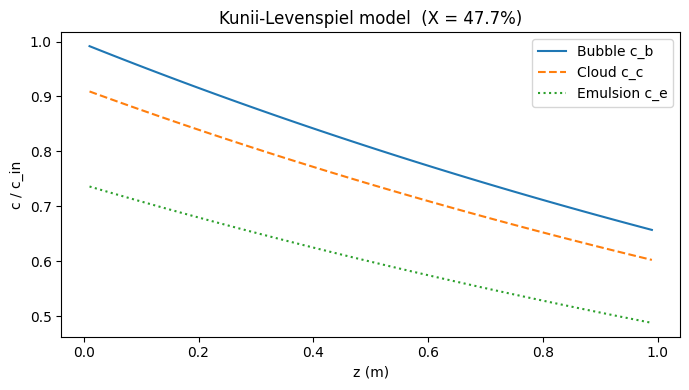

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# ── Kunii-Levenspiel correlations ─────────────────────────────────
def kl_params(U, U_mf, d_b, Dm, eps_mf, g=9.81):
    U_b  = (U - U_mf) + 0.711 * np.sqrt(g * d_b)
    delta = (U - U_mf) / U_b
    K_bc  = 4.5 * U_mf/d_b + 5.85 * np.sqrt(Dm) * g**0.25 / d_b**1.25
    K_ce  = 6.77 * np.sqrt(Dm * U_b / d_b**3)
    return U_b, delta, K_bc, K_ce

# ── System parameters ─────────────────────────────────────────────
L_bed  = 1.0         # bed height [m]
N      = 50
dz     = L_bed / N
z      = (np.arange(N) + 0.5) * dz

U      = 0.15        # superficial gas velocity [m/s]
U_mf   = 0.02        # min fluidization velocity [m/s]
eps_mf = 0.45        # void fraction at mf
d_b    = 0.05        # mean bubble diameter [m]
Dm     = 1e-5        # molecular diffusivity [m²/s]
k_r    = 1.0         # reaction rate in emulsion [1/s]
c_in   = 1.0         # inlet concentration [mol/m³]

U_b, delta, K_bc, K_ce = kl_params(U, U_mf, d_b, Dm, eps_mf)
print(f'U_b  = {U_b:.3f} m/s')
print(f'delta = {delta:.3f}  (bubble fraction)')
print(f'K_bc = {K_bc:.3f} 1/s,  K_ce = {K_ce:.3f} 1/s')

# ── Build system of 3 coupled ODEs ────────────────────────────────
# Bubble: U_b dc_b/dz + K_bc (c_b - c_c) = 0  (FOU upwind)
# Cloud:  K_bc(c_b-c_c) - K_ce(c_c-c_e) = 0   (algebraic)
# Emulsion: K_ce(c_c-c_e) - (1-delta)*eps_mf*k_r*c_e = 0 (algebraic)
#
# Solve cloud and emulsion as linear functions of c_b per cell:
# From emulsion: c_e = K_ce*c_c / (K_ce + (1-delta)*eps_mf*k_r)
# From cloud balance: K_bc*c_b = K_bc*c_c + K_ce*(c_c - c_e)

gamma = (1-delta) * eps_mf * k_r
# c_e = K_ce * c_c / (K_ce + gamma)
# K_bc*(c_b - c_c) = K_ce*(c_c - K_ce*c_c/(K_ce+gamma))
#                   = K_ce*c_c*gamma/(K_ce+gamma)
# => c_c = K_bc*(K_ce+gamma)/(K_bc*(K_ce+gamma) + K_ce*gamma) * c_b
denom_c = K_bc*(K_ce + gamma) + K_ce*gamma
alpha_c = K_bc*(K_ce + gamma) / denom_c
alpha_e = K_bc*K_ce / denom_c

# Effective sink rate on bubble phase
k_eff = K_bc * (1 - alpha_c) / 1.0   # approximate
# More precisely from energy balance:
# U_b dc_b/dz = -K_bc(c_b - alpha_c*c_b) = -K_bc*(1-alpha_c)*c_b
k_b_eff = K_bc * (1 - alpha_c)

# 1D ODE for c_b (bubble phase convection)
off_b = U_b / dz
A_b   = sp.diags([-off_b, off_b + k_b_eff, 0*np.ones(N-1)],
                  [-1, 0, 1], shape=(N, N), format='csr')
rhs_b = np.zeros(N); rhs_b[0] += off_b * c_in
c_b   = spla.spsolve(A_b, rhs_b)
c_c   = alpha_c * c_b
c_e   = alpha_e * c_b

# Overall outlet concentration (flow-weighted)
c_out = delta*c_b[-1] + (1-delta)*c_e[-1]
X_conv = 1 - c_out / c_in
print(f'\nConversion X = {X_conv*100:.1f}%')

plt.figure(figsize=(7, 4))
plt.plot(z, c_b, label='Bubble c_b')
plt.plot(z, c_c, '--', label='Cloud c_c')
plt.plot(z, c_e, ':', label='Emulsion c_e')
plt.xlabel('z (m)'); plt.ylabel('c / c_in')
plt.title(f'Kunii-Levenspiel model  (X = {X_conv*100:.1f}%)')
plt.legend(); plt.tight_layout(); plt.show()

## Sensitivity: Effect of superficial velocity

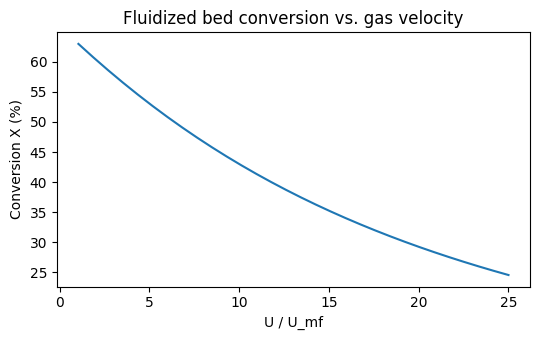

In [2]:
U_vals = np.linspace(U_mf*1.05, 0.5, 30)
X_vals = []
for U_v in U_vals:
    U_bv, delta_v, Kbc_v, Kce_v = kl_params(U_v, U_mf, d_b, Dm, eps_mf)
    gamma_v = (1-delta_v)*eps_mf*k_r
    denom_v = Kbc_v*(Kce_v+gamma_v) + Kce_v*gamma_v
    alpha_cv = Kbc_v*(Kce_v+gamma_v)/denom_v
    k_bv = Kbc_v*(1-alpha_cv)
    Av = sp.diags([-U_bv/dz, U_bv/dz + k_bv], [-1, 0], shape=(N, N), format='csr')
    rhs_v = np.zeros(N); rhs_v[0] += U_bv/dz * c_in
    try:
        cb_v = spla.spsolve(Av, rhs_v)
        alpha_ev = Kbc_v*Kce_v/denom_v
        ce_v = alpha_ev * cb_v
        X_vals.append(1 - (delta_v*cb_v[-1] + (1-delta_v)*ce_v[-1])/c_in)
    except Exception:
        X_vals.append(np.nan)

plt.figure(figsize=(5.5, 3.5))
plt.plot(U_vals/U_mf, [x*100 for x in X_vals])
plt.xlabel('U / U_mf'); plt.ylabel('Conversion X (%)')
plt.title('Fluidized bed conversion vs. gas velocity')
plt.tight_layout(); plt.show()

## Summary

- Above $U_{mf}$ bubbles carry most of the gas → bypassing of reactant
- K-L model provides three-phase description: bubble, cloud, emulsion
- $K_{bc}$ and $K_{ce}$ control inter-phase exchange; larger $d_b$ means poorer exchange
- Higher $U$ increases bubble size → more bypassing → lower conversion
- Real beds: use Werther bubble-size correlation for $d_b(z)$ that varies with height